In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the CoolTrack package
from cooltrack.constants import INDEPENDENT_DIMS, Bands
from cooltrack.models import ThermalEvolutionModels
from cooltrack.integrator import CoolingIntegrator
from cooltrack.initial_conditions import InitialConditions
from cooltrack.smoothing import TrackSmoother

sns.set_theme(style="whitegrid", context="talk")

# Paths to the lightweight data (NO PARQUET GRIDS NEEDED!)
MODELS_DIR = "../data/models/"
AGE_DATA_PATH = "../data/age_data/"

In [2]:
print("Loading pre-trained ML models from disk...")
ml_engine = ThermalEvolutionModels()
ml_engine.load_models(MODELS_DIR)

print("Initializing Boundary Conditions and Integrator...")
init_cond = InitialConditions(AGE_DATA_PATH)
integrator = CoolingIntegrator(ml_engine)

print("Engine is completely loaded and ready for inference!")

2026-03-02 17:10:12,663 - INFO - Loading models from ../data/models/...


Loading pre-trained ML models from disk...


2026-03-02 17:10:14,304 - INFO - All models loaded successfully.
2026-03-02 17:10:14,331 - INFO - Loaded initial condition interpolators from 4 files.


Initializing Boundary Conditions and Integrator...
Engine is completely loaded and ready for inference!


In [3]:
# --- 1. Define Custom Planet Parameters ---
# Must match the features expected by INDEPENDENT_DIMS: 
# ['mass_Mj', 'T_irr', 'Met', 'core', 'f_sed', 'kzz']

custom_planet = pd.Series({
    'mass_Mj': 10.0,               # 1 Jupiter Mass
    'T_irr': 150.0,               # 150 K
    'Met': np.log10(3),         # 3x Solar Metallicity
    'core': 10.0,                 # 10 Earth Mass Core
    'f_sed': 1.0,                 # Standard sedimentation
    'kzz': 8.0                    # 10^8 cm^2/s
})

print("Simulating Custom Planet:")
for key, val in custom_planet.items():
    if key == 'Met':
        print(f" - {key}: {val:.3f} (which is {10**val:.1f}x Solar)")
    elif key == 'kzz':
        print(f" - {key}: {val:.1f} (which is 10^{val:.0f} cm^2/s)")
    else:
        print(f" - {key}: {val}")

# --- 2. Define Entropy Boundaries ---
# Get the hot-start entropy based purely on the mass
s_hot_start = init_cond.get_starting_physical_entropy(custom_planet['mass_Mj'])

# Since we don't have the grid, we manually set a realistic cold boundary limit.
# For Jupiter-like planets, ~5.8 to 6.0 J/K/kg represents an extremely old, cold state.
S_COLD_END = 5.8 

# --- 3. Integrate the Track! ---
print(f"\nIntegrating from S0 = {s_hot_start:.2f} down to {S_COLD_END:.2f}...")
ages, entropies = integrator.calculate_track(custom_planet, s_hot_start, S_COLD_END, num_points=250)

if ages is None:
    print("Integration failed. Try checking if your parameters are within the grid's physical bounds.")
else:
    print(f"Integration successful! Generated {len(ages)} time steps spanning up to {ages[-1]/1e9:.2f} Billion Years.")

Simulating Custom Planet:
 - mass_Mj: 10.0
 - T_irr: 150.0
 - Met: 0.477 (which is 3.0x Solar)
 - core: 10.0
 - f_sed: 1.0
 - kzz: 8.0 (which is 10^8 cm^2/s)

Integrating from S0 = 95138.09 down to 5.80...
Integration successful! Generated 250 time steps spanning up to 6902.48 Billion Years.


Bands.find(): Guessed 'MIRI_F1000W' from input 'miri 1000'
Bands.find(): Guessed 'NIRISS_F480M' from input 'niriss 480'
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


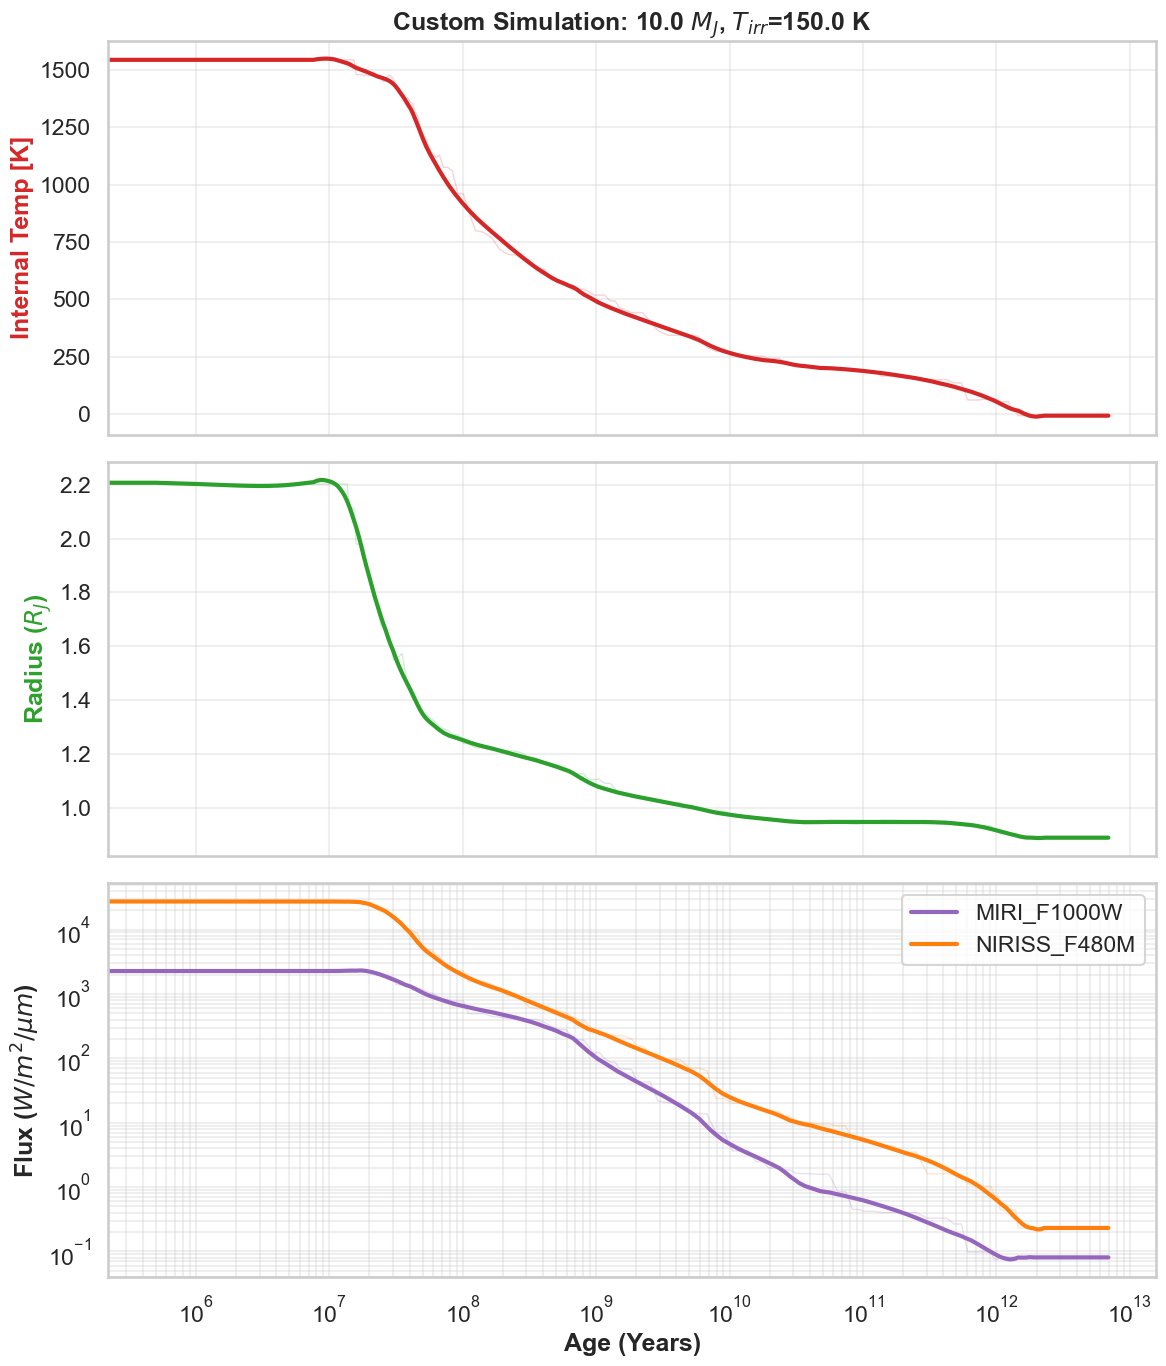

In [4]:
if ages is not None:
    # --- Predict Observables ---
    fixed_params = custom_planet[INDEPENDENT_DIMS].values.astype(float)
    t_ints_raw, radii_raw, flux_1_raw, flux_2_raw = [], [], [], []
    
    # Choose your JWST filters using the fuzzy finder!
    band_1 = Bands.find('miri 1000')
    band_2 = Bands.find('niriss 480')
    
    for s in entropies:
        inp = np.append(fixed_params, s).reshape(1, -1)
        
        # State Predictions
        t_ints_raw.append(ml_engine.tint_model.predict(inp)[0])
        radii_raw.append(ml_engine.radius_model.predict(inp)[0])
        
        # Photometry Predictions (Un-log them!)
        flux_1_raw.append(10 ** ml_engine.photo_models[band_1].predict(inp)[0])
        flux_2_raw.append(10 ** ml_engine.photo_models[band_2].predict(inp)[0])

    # --- Smooth the Tracks ---
    ages_arr = np.array(ages)
    
    t_smooth = TrackSmoother.smooth(ages_arr, np.array(t_ints_raw), method='savgol', window_length=31, polyorder=3)
    r_smooth = TrackSmoother.smooth(ages_arr, np.array(radii_raw), method='savgol', window_length=31, polyorder=3)
    f1_smooth = TrackSmoother.smooth(ages_arr, np.log10(np.array(flux_1_raw)), method='savgol', window_length=31)
    f2_smooth = TrackSmoother.smooth(ages_arr, np.log10(np.array(flux_2_raw)), method='savgol', window_length=31)
    ages_smooth = TrackSmoother.smooth(ages_arr, ages_arr, method='savgol', window_length=31)

    # --- 3-Panel Plot ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    
    # T_int
    ax1.plot(ages_arr, t_ints_raw, color='tab:red', lw=1, alpha=0.2)
    ax1.plot(ages_smooth, t_smooth, color='tab:red', lw=3)
    ax1.set_ylabel('Internal Temp [K]', color='tab:red', fontweight='bold')
    ax1.set_title(f"Custom Simulation: {custom_planet['mass_Mj']} $M_J$, $T_{{irr}}$={custom_planet['T_irr']} K", fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Radius
    ax2.plot(ages_arr, radii_raw, color='tab:green', lw=1, alpha=0.2)
    ax2.plot(ages_smooth, r_smooth, color='tab:green', lw=3)
    ax2.set_ylabel('Radius ($R_J$)', color='tab:green', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Photometry
    ax3.plot(ages_arr, flux_1_raw, color='tab:purple', lw=1, alpha=0.2)
    ax3.plot(ages_smooth, 10**f1_smooth, color='tab:purple', lw=3, label=band_1.replace('_Flambda_wm2um', ''))
    
    ax3.plot(ages_arr, flux_2_raw, color='tab:orange', lw=1, alpha=0.2)
    ax3.plot(ages_smooth, 10**f2_smooth, color='tab:orange', lw=3, label=band_2.replace('_Flambda_wm2um', ''))
    
    ax3.set_ylabel('Flux ($W/m^2/\mu m$)', fontweight='bold')
    ax3.set_xlabel('Age (Years)', fontweight='bold')
    ax3.set_yscale('log') 
    ax3.set_xscale('log')
    ax3.legend(loc="upper right")
    ax3.grid(True, which="both", alpha=0.3)
    
    fig.tight_layout()
    plt.show()